In [1]:
from sklearn.datasets import fetch_openml

In [2]:
mnist = fetch_openml('mnist_784', as_frame=False)

In [3]:
X, y = mnist.data, mnist.target

In [4]:
X.shape

(70000, 784)

In [5]:
y.shape

(70000,)

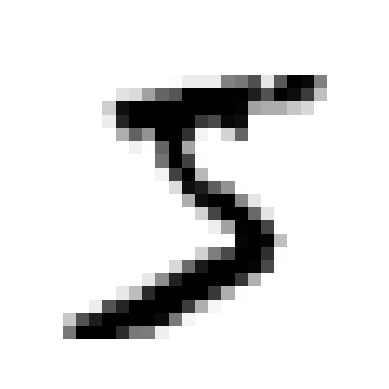

In [6]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28,28)
    plt.imshow(image, cmap='binary')
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [7]:
y[0]

'5'

In [8]:
x_train, x_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

ensure to always shuffle the training and test sets..

training a binary classifier...

In [9]:
# simple 5 or non 5s classifier
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

using SGDClassifer:
- SGDClassifier isn't one classifier but its a training engine for linear classifiers
- it learns the model: z = w1x1 + w2x2 + .... + wnxn + b
- predicts if z>=0; class 1 otherwise class 0
- implements stochastic gradient descent implying that results are updated for one row of data (weights are updated for one row and so on..not batches)

In [10]:
from sklearn.linear_model import SGDClassifier

In [11]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(x_train, y_train_5)

SGDClassifier(random_state=42)

sklearn's SGDClassifier is capable of handling large datasets efficiently. this is in part because SGD deals with datasets independently, one at a time. making it suited for online learning

In [12]:
some_digit.shape

(784,)

In [13]:
sgd_clf.predict(some_digit.reshape(1,-1))

array([ True])

**Performance Measures for classification:**

a good way to eval a model is to use cross validation. 

In [14]:
from sklearn.model_selection import cross_val_score

cross val score is a wrapper around StratifiedKFold...instead of manually using the splitter we can just use the cross_val_score scorer and get the score in one line...for classification, the default splitter used will be StratifiedKFold..

In [16]:
cross_val_score(sgd_clf, x_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

evaluated using accuracy:
- remember accuracy = (correct predictions)/(all predictions)
- so if there's class imbalance, predicting the most dominant class will still result in a high accuracy score (**bug**)

In [18]:
from sklearn.dummy import DummyClassifier

In [19]:
dummy_clf = DummyClassifier()
dummy_clf.fit(x_train, y_train_5)

DummyClassifier()

In [20]:
cross_val_score(dummy_clf, x_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

dummy does so well as well....still by predicting the most dominant class. hence showing that accuracy isn't a good metric for this dataset's evaluation.

**confusion matrices**

In [21]:
from sklearn.model_selection import cross_val_predict

In [22]:
y_train_pred = cross_val_predict(sgd_clf, x_train, y_train_5, cv=3)
# using the cross val predict function, which like the cross_val_score function performs k-fold cross validation, but instead of returning evaluation scores, it returns the predictions made on each test fold.
# implying, you get a clean prediction for each instance in the training set (out of sample predictions)

the predictions returned by cross_val_predict are aligned to the original row ordering of the input x and y.

In [23]:
from sklearn.metrics import confusion_matrix

In [24]:
cm = confusion_matrix(y_train_5, y_train_pred)

In [25]:
cm

array([[53892,   687],
       [ 1891,  3530]])

confusion matrix above:
- rows: actual classes and cols: predicted classes
- first row: non-5 imahes (negative class) | 

precision and recall:
- sklearn provides several functions to compute classifier metrics, including precision and recall..

In [26]:
from sklearn.metrics import recall_score, precision_score

In [27]:
precision_score(y_train_5, y_train_pred)

0.8370879772350012

In [28]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

- we have an imbalanced dataset. most dominant class is the negative (0 class -> which stands for not 5s) | the least dominant class is the positive class (1s, 5s) | due to the imbalance, the model is biased towards making predictions biased towards the negative class..has learned a lot about the negative class and thinks everything is negative, hence, it will likely think everything is negative | because of this, its accuracy will still be high anyway, since the class is imbalanced and precision decent as its less likely to make a positive prediction. | on the other hand, the recall will by abysmal, since there's many false negatives (true positives misclassified as negatives)

- summary: 
  - if your dataset has mainly negative labels - they'll get polluted by the least dominant class (recall will be low, precision mildly decent and accuracy probably high)
  - if the dataset has mainly positive predictions - they'll get polluted by the least dominant class whose features aren't learned well (recall will be mildly decent, precision abysmal, accuracy probably high)

In [29]:
# combination to produce the harmonic mean - f1 score
# harmonic means like f1 score gives much more weight to low values - as a result the classifier will only get a high f1 score if both precision and recall are high
from sklearn.metrics import f1_score

In [30]:
f1_score(y_train_5, y_train_pred)

0.7325171197343847

lowering or increasing the model's decision threshold can result in a high precision/high recall

instead of calling the classifier's predict method....you can call its decision_function() method instead, which returns a score for each instance...can then use any threshold you want to make predictions based on those scores

In [31]:
y_scores = sgd_clf.decision_function([some_digit])

In [32]:
y_scores

array([2164.22030239])

In [33]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

SGD Classifier uses a threshold equal to 0, so, the preceding code returns the same result as the predict mthod..lets now raise the threshold...

In [34]:
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

raising the threshold, decreases the recall...

In [35]:
y_scores = cross_val_predict(sgd_clf, x_train, y_train_5, cv=3, method="decision_function")

with these scores, use the precision_recall_curve function to compute precision and recall for all possible thresholds....(the function adds a last precision of 1 and last recall or 0, corresponding to an infinite threshold)

In [36]:
from sklearn.metrics import precision_recall_curve

In [37]:
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

In [38]:
len(thresholds), len(precisions), len(recalls)

(60000, 60001, 60001)

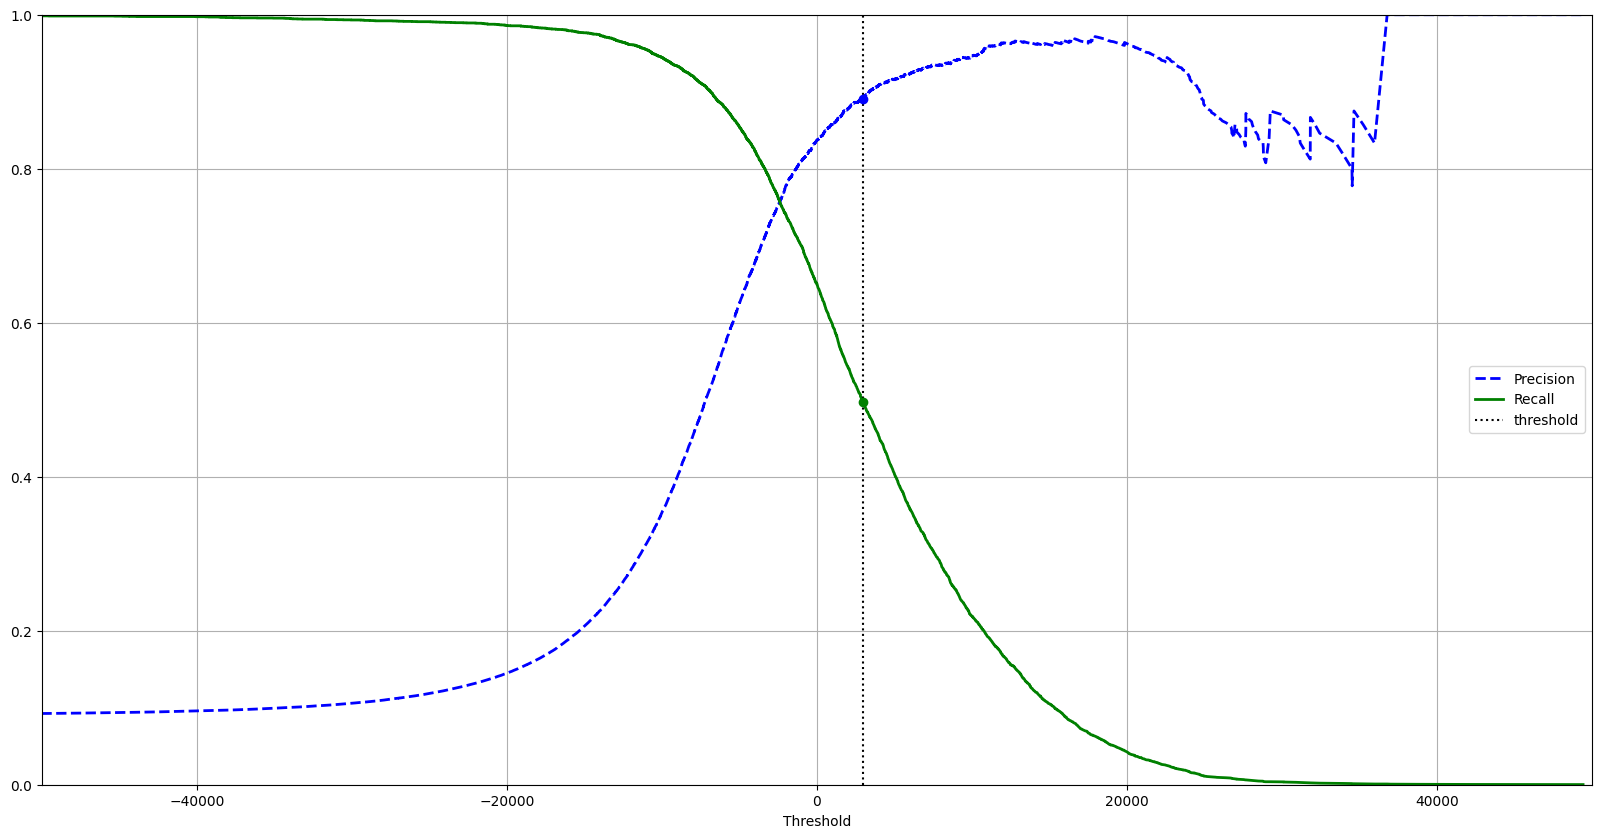

In [43]:
fig, ax = plt.subplots(figsize=(20,10))

ax.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
ax.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
ax.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

# extra code 
idx = (thresholds >= threshold).argmax() # the first index >= threshold
ax.plot(thresholds[idx], precisions[idx], "bo")
ax.plot(thresholds[idx], recalls[idx], "go")
ax.axis([-50000,50000,0,1])
ax.grid()
plt.xlabel("Threshold")
ax.legend(loc="center right")

doing this again but for probability scores...

another way to set a good precision-recall trade-off is to plot precision directly against recalll...

In [49]:
import matplotlib.patches as patches

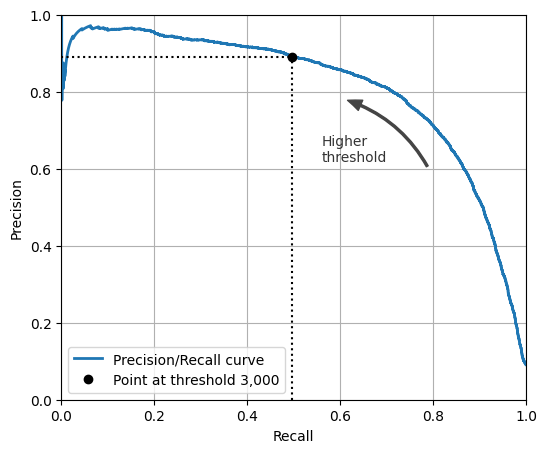

In [50]:
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(recalls, precisions, linewidth=2,label="Precision/Recall curve")
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Point at threshold 3,000")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")
plt.show()

suppose yuou decide to aim for 90% precision, can use the first plot to find the threshold you need to use. alternatively, can search for the lowest threshold that gives you at least 90% precision. for this, use numpy's argmax() method, which returns the first index of the maximum value. which in this case is the true value...

In [51]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision 

3370.019499144183

to make predictions, then, instead of calling the classifier's predict method, run the code below:

In [52]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

then, check these predictions' precision and recall..

In [53]:
from sklearn.metrics import precision_score, recall_score

In [54]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [55]:
recall_score(y_train_5, y_train_pred_90)

0.4799852425751706

Sklearn -> 
- 2 new classes to more easily adjust the decision_threshold...
  - FixedThresholdClassifier: lets you wrap a binary classfier and set the threshold manually. if underlying class has a predict_proba method then the threshold should be a value between 0 and 1 (default is 0.5). 
  - TunedThresholdClassifierCV: uses k-fold cross validation to automatically find the optimal threshold for a given metric. by default, it tries to find the threshold that maximizes the model's balanced accuracy: i.e. the average of each class's recall..

**ROC Curve:**
- the receiver_operating_xtic(similar to precision/recall curve). plots true positive rate (recall) against the false positive rate (fallout)

In [56]:
# to plot:
from sklearn.metrics import roc_curve

In [57]:
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

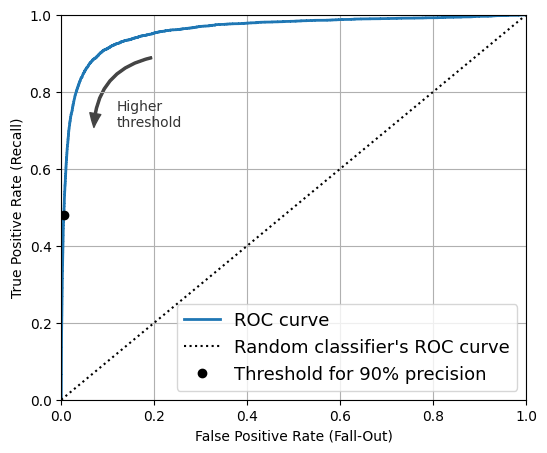

In [58]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

# extra code – just beautifies Figure 3–7
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)

plt.show()

again there's a tradeoff: the higher the recall (TPR), the more false positives (FPR), the classifier produces. The dotted line represents the roc curve, of a purely random classifier.  | comparing classifiers with this metric is by looking at the area under the curve (AUC) metric. perfect classifier has a ROC AUC score of close to 1. 

**Now, we create a RandomForestClassifier whose PR curve and F1 score we can compare to those of the SGDClassifier:**

In [59]:
from sklearn.ensemble import RandomForestClassifier

In [60]:
forest_clf = RandomForestClassifier(random_state=42)

In [61]:
y_probas_forest = cross_val_predict(forest_clf, x_train, y_train_5, cv=3, method="predict_proba")

In [62]:
# probabilities of the first 2 images in the training set:
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.98, 0.02]])

to make actual use of probability scores -  check the calibrated probabilities by cross validation function in sklearn...

the second col contains probabilities for the positive class, so we pass them to the precision_recall_curve function:

In [63]:
y_scores_forest = y_probas_forest[:, 1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(y_train_5, y_scores_forest)

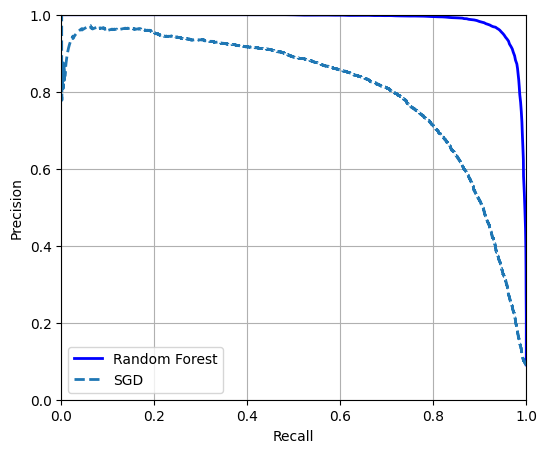

In [64]:
plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2,
         label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")

# extra code – just beautifies Figure 3–8
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")

plt.show()

random forest classifier's pr curve looks much better than the SGDClassifier's it comes much closer to the top right corner. and its f1 score and roc auc score also significantly vetter,

**Error Analysis:**
- found a promising model - to improve it, one way to do this is by analysing the types of errors it makes...
- first look at the confusion matrrix..for this you need to make predictions using the cross_val_predict function... then pass the labels and predictions to the confusion_matrix function..

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay

In [66]:
y_pred_forest = cross_val_predict(forest_clf, x_train, y_train_5, cv=3, method="predict")

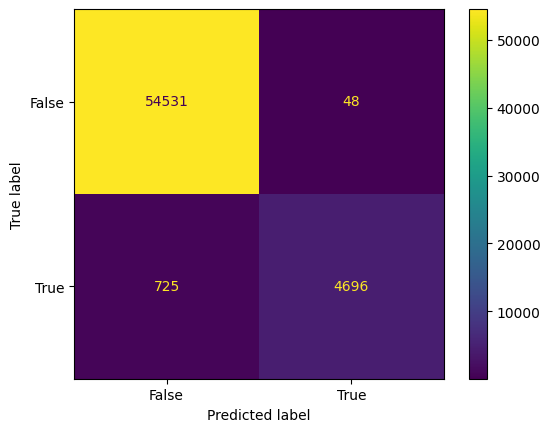

In [67]:
ConfusionMatrixDisplay.from_predictions(y_train_5, y_pred_forest)
plt.show()

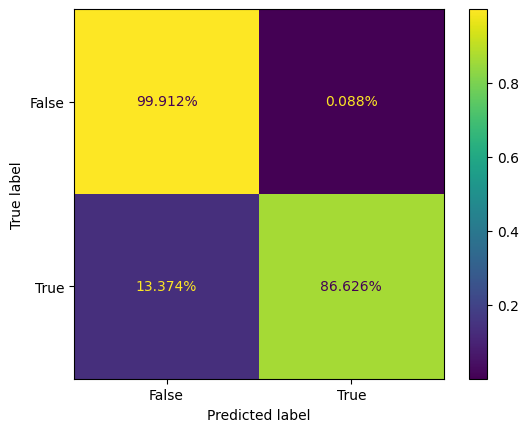

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_train_5, y_pred_forest, normalize="true", values_format="2.3%")
plt.show()

see the types of errors the model is making, and where its making them,....then target that to improve...

**Multilabel Classification:**
- classifier to output multiple classes ..can try using kneighborsclassifier..

In [77]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

In [78]:
y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8') % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

In [79]:
y_multilabel.shape

(60000, 2)

In [80]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(x_train, y_multilabel)

KNeighborsClassifier()

In [81]:
knn_clf.predict(some_digit.reshape(1,-1))

array([[False,  True]])

first digit -> 5 -> is not large but odd...so pred is true..

many ways to eval a multilabel classifier and selecting the right metric depends on the project. one approach is to measure the f1 score for each individual label then simply compute the average score... the following code computes the average f1 score across all labels...

In [82]:
y_train_knn_pred = cross_val_predict(knn_clf, x_train, y_multilabel, cv=3)

f1_score(y_multilabel, y_train_knn_pred, average="macro")

0.9764102655606048